In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd "/content/drive/MyDrive/Final/Final-Assignment"

/content/drive/MyDrive/Final/Final-Assignment


## Environment Setup

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
from google.colab import files
from pathlib import Path
import shutil
import xgboost as xgb
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    precision_recall_curve, average_precision_score, ConfusionMatrixDisplay
)

In [4]:
sns.set_theme(style='whitegrid', palette='viridis', font_scale=1.15)
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

## Data Ingestion & Merging

In [5]:
PATH = Path.cwd() / "telecom"

client_file = PATH / "Client.csv"
record_file = PATH / "Record.csv"

# Check if path exists
if client_file.exists() and record_file.exists():
    print("All files exist and path is correctly set.")
else:
    print("Some files are missing or path is not correctly set.")

All files exist and path is correctly set.


In [6]:
# Load data
PATH = Path.cwd() / "telecom"

client = pd.read_csv(PATH / "Client.csv")
record = pd.read_csv(PATH / "Record.csv")

print(f'Client shape: {client.shape}')
print(f'Record shape: {record.shape}')
print(f'Shared key (Customer_ID) overlap: {len(set(client.Customer_ID) & set(record.Customer_ID)):,}')

Client shape: (100000, 50)
Record shape: (100000, 51)
Shared key (Customer_ID) overlap: 100,000


In [7]:
# Merge on Customer_ID (inner join to keep only matched records)
df = pd.merge(client, record, on='Customer_ID', how='inner')
print(f'Merged dataset shape: {df.shape}')
print(f'Duplicate Customer_IDs: {df.Customer_ID.duplicated().sum()}')
df.head(3)

Merged dataset shape: (100000, 100)
Duplicate Customer_IDs: 0


,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,...,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months
0,2,1,U,A,N,1652,4228.00000,1504.62,1453.44,4085.00,...,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61
1,1,1,N,EA,N,14654,26400.00000,2851.68,2833.88,26367.00,...,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56
2,1,1,Y,C,N,7903,24385.05333,2155.91,1934.47,24303.05,...,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58


In [8]:
# Quick data quality overview
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct})
miss_df = miss_df[miss_df.Missing > 0].sort_values('Pct', ascending=False)

print(f'\nColumns with missing values: {len(miss_df)}')
print(f'Total columns: {df.shape[1]}\n')
miss_df.head(15)


Columns with missing values: 43
Total columns: 100



,Missing,Pct
numbcars,49366,49.37
dwllsize,38308,38.31
HHstatin,37923,37.92
ownrent,33706,33.71
dwlltype,31909,31.91
lor,30190,30.19
income,25436,25.44
adults,23019,23.02
infobase,22079,22.08
hnd_webcap,10189,10.19


## Exploratory Data Analysis & Hypothesis Generation

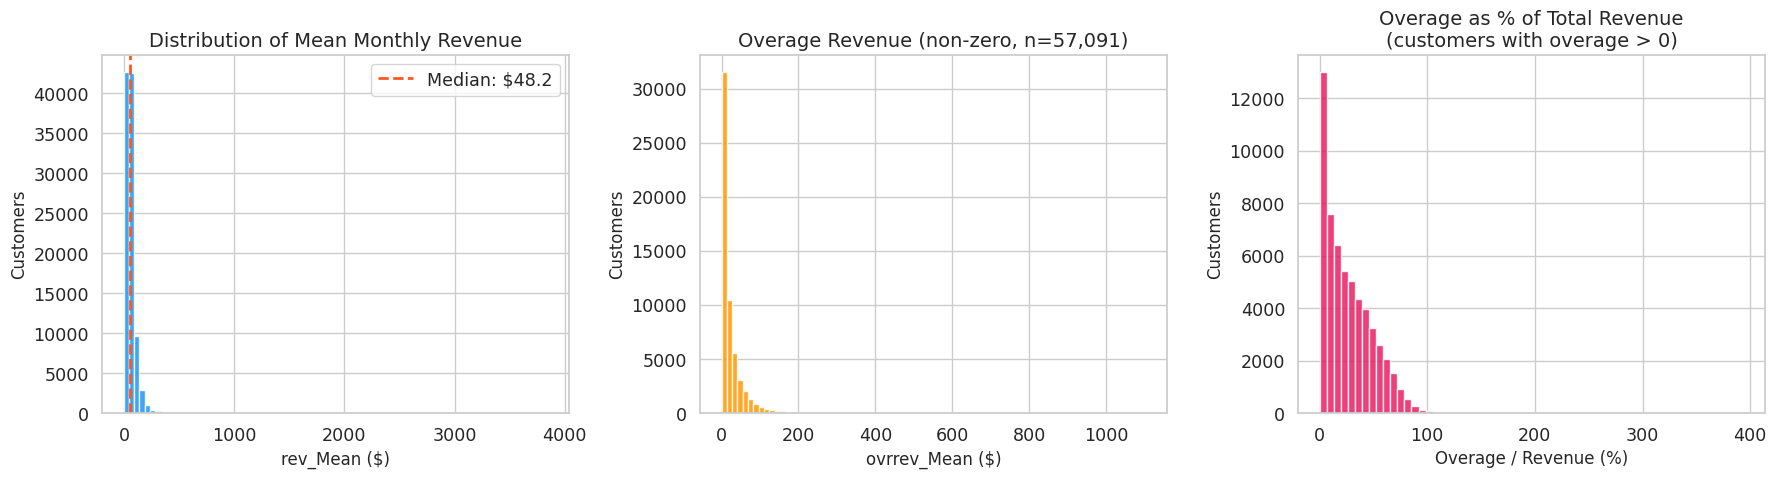

Customers with ANY overage: 57,091  (57.1%)
Median overage (non-zero): $11.20
Mean overage (non-zero):   $23.67
Top 5% overage threshold:  $86.56


In [9]:
# Revenue & Overage Distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Total Revenue distribution
axes[0].hist(df['rev_Mean'].dropna(), bins=80, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0].axvline(df['rev_Mean'].median(), color='#FF5722', ls='--', lw=2, label=f"Median: ${df['rev_Mean'].median():.1f}")
axes[0].set_title('Distribution of Mean Monthly Revenue')
axes[0].set_xlabel('rev_Mean ($)')
axes[0].set_ylabel('Customers')
axes[0].legend()

# Overage Revenue distribution
ovr_nonzero = df.loc[df['ovrrev_Mean'] > 0, 'ovrrev_Mean']
axes[1].hist(ovr_nonzero, bins=80, color='#FF9800', edgecolor='white', alpha=0.85)
axes[1].set_title(f'Overage Revenue (non-zero, n={len(ovr_nonzero):,})')
axes[1].set_xlabel('ovrrev_Mean ($)')
axes[1].set_ylabel('Customers')

# Overage as % of Total Revenue (for those with overage > 0)
mask = (df['ovrrev_Mean'] > 0) & (df['rev_Mean'] > 0)
ovr_ratio = (df.loc[mask, 'ovrrev_Mean'] / df.loc[mask, 'rev_Mean'] * 100)
axes[2].hist(ovr_ratio, bins=60, color='#E91E63', edgecolor='white', alpha=0.85)
axes[2].set_title('Overage as % of Total Revenue\n(customers with overage > 0)')
axes[2].set_xlabel('Overage / Revenue (%)')
axes[2].set_ylabel('Customers')

plt.tight_layout()
plt.show()

# Key stats
print(f"Customers with ANY overage: {(df['ovrrev_Mean'] > 0).sum():,}  "
      f"({(df['ovrrev_Mean'] > 0).mean()*100:.1f}%)")
print(f"Median overage (non-zero): ${ovr_nonzero.median():.2f}")
print(f"Mean overage (non-zero):   ${ovr_nonzero.mean():.2f}")
print(f"Top 5% overage threshold:  ${ovr_nonzero.quantile(0.95):.2f}")

In [10]:
# Define Target Variable: Overage Upsell Candidate
df['overage_pct'] = np.where(
    df['rev_Mean'] > 0,
    df['ovrrev_Mean'] / df['rev_Mean'] * 100,
    0
)

ovr_q75 = df.loc[df['ovrrev_Mean'] > 0, 'ovrrev_Mean'].quantile(0.75)

df['upsell_candidate'] = (
    ((df['overage_pct'] >= 15) | (df['ovrrev_Mean'] >= ovr_q75)) &
    (df['ovrrev_Mean'] > 0)
).astype(int)

print(f"Overage Q75 threshold: ${ovr_q75:.2f}")
print(f"\nTarget distribution:")
print(df['upsell_candidate'].value_counts())
print(f"\nPositive rate: {df['upsell_candidate'].mean()*100:.2f}%")

Overage Q75 threshold: $29.20

Target distribution:
upsell_candidate
0    65387
1    34613
Name: count, dtype: int64

Positive rate: 34.61%


In [11]:
# Deep-dive: Upsell Candidates vs Regular Customers
compare_cols = ['rev_Mean', 'totmrc_Mean', 'mou_Mean', 'ovrmou_Mean',
                'ovrrev_Mean', 'drop_vce_Mean', 'change_mou', 'change_rev',
                'totrev', 'months']

comparison = df.groupby('upsell_candidate')[compare_cols].median().T
comparison.columns = ['Regular', 'Upsell Candidate']
comparison['Lift (%)'] = ((comparison['Upsell Candidate'] / comparison['Regular'] - 1) * 100).round(1)
comparison.style.format('{:.2f}').background_gradient(subset=['Lift (%)'], cmap='RdYlGn')

,Regular,Upsell Candidate,Lift (%)
rev_Mean,38.46,68.75,78.70
totmrc_Mean,44.99,44.99,0.00
mou_Mean,242.75,624.00,157.10
ovrmou_Mean,0.00,69.75,inf
ovrrev_Mean,0.00,23.80,inf
drop_vce_Mean,2.00,5.67,183.30
change_mou,-5.25,-13.25,152.40
change_rev,-0.25,-6.67,2597.00
totrev,744.75,929.04,24.70
months,17.00,16.00,-5.90


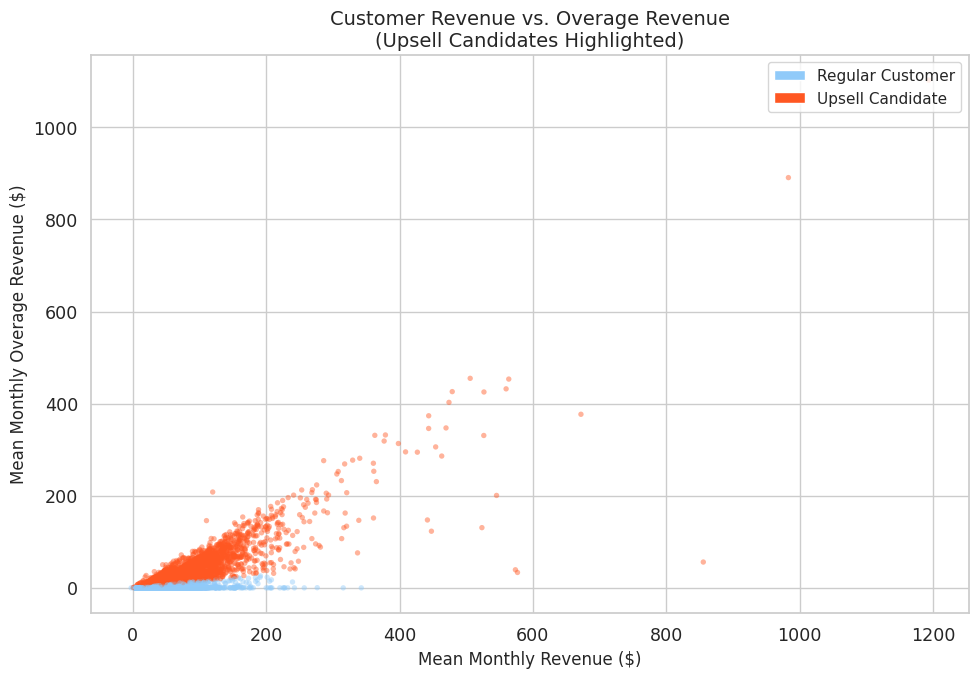

In [12]:
# Revenue vs Overage Scatterplot (sampled for speed)
sample = df.sample(min(10000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sample['upsell_candidate'].map({0: '#90CAF9', 1: '#FF5722'})
ax.scatter(sample['rev_Mean'], sample['ovrrev_Mean'],
           c=colors, alpha=0.45, s=15, edgecolors='none')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#90CAF9', label='Regular Customer'),
    Patch(facecolor='#FF5722', label='Upsell Candidate'),
], loc='upper right', fontsize=11)

ax.set_xlabel('Mean Monthly Revenue ($)')
ax.set_ylabel('Mean Monthly Overage Revenue ($)')
ax.set_title('Customer Revenue vs. Overage Revenue\n(Upsell Candidates Highlighted)')
plt.tight_layout()
plt.show()

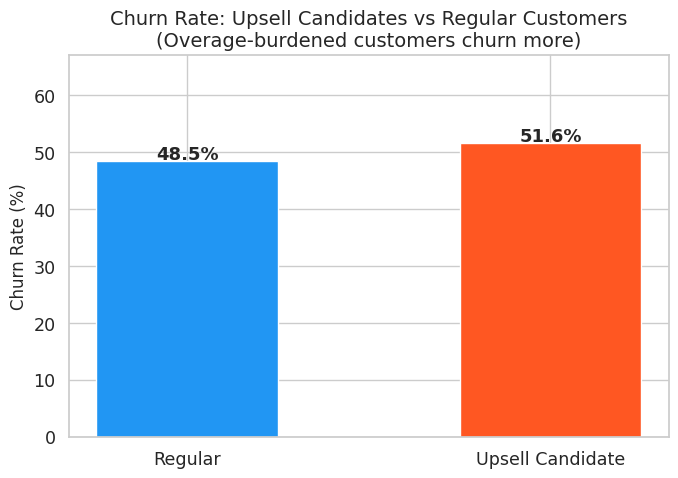

In [13]:
# Churn Rate Among Upsell Candidates vs Regular
churn_by_upsell = df.groupby('upsell_candidate')['churn'].agg(['mean', 'count'])
churn_by_upsell.columns = ['Churn Rate', 'Count']
churn_by_upsell.index = ['Regular', 'Upsell Candidate']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(churn_by_upsell.index, churn_by_upsell['Churn Rate'] * 100,
              color=['#2196F3', '#FF5722'], edgecolor='white', width=0.5)
for bar, rate in zip(bars, churn_by_upsell['Churn Rate'] * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate:.1f}%', ha='center', fontsize=13, fontweight='bold')
ax.set_ylabel('Churn Rate (%)')
ax.set_title('Churn Rate: Upsell Candidates vs Regular Customers\n(Overage-burdened customers churn more)')
ax.set_ylim(0, max(churn_by_upsell['Churn Rate'] * 100) * 1.3)
plt.tight_layout()
plt.show()

## Feature Engineering & Preprocessing

In [14]:
# Handle Missing Values
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove identifiers / targets from feature lists
exclude = ['Customer_ID', 'upsell_candidate', 'overage_pct']
num_cols = [c for c in num_cols if c not in exclude]
cat_cols = [c for c in cat_cols if c not in exclude]

print(f'Numeric features: {len(num_cols)}')
print(f'Categorical features: {len(cat_cols)}')

# Impute
for c in num_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].median())

for c in cat_cols:
    if df[c].isnull().any():
        df[c] = df[c].fillna(df[c].mode()[0])

print(f'\nRemaining missing values: {df[num_cols + cat_cols].isnull().sum().sum()}')


Numeric features: 78
Categorical features: 21

Remaining missing values: 0


In [15]:
# Custom Business Features
df['Overage_to_Revenue_Ratio'] = np.where(
    df['rev_Mean'] > 0,
    df['ovrrev_Mean'] / df['rev_Mean'],
    0
)

# Usage Dropoff Rate
df['Usage_Dropoff_Rate'] = np.where(
    df['mou_Mean'] > 0,
    df['change_mou'] / df['mou_Mean'],
    0
)

# Revenue Efficiency (revenue per minute of use)
df['Revenue_Per_MOU'] = np.where(
    df['mou_Mean'] > 0,
    df['rev_Mean'] / df['mou_Mean'],
    0
)

new_features = ['Overage_to_Revenue_Ratio', 'Usage_Dropoff_Rate', 'Revenue_Per_MOU']
df[new_features].describe().round(4)

,Overage_to_Revenue_Ratio,Usage_Dropoff_Rate,Revenue_Per_MOU
count,100000.0000,100000.0000,100000.0000
mean,0.1508,-0.0435,0.5649
std,0.2122,0.5297,5.0037
min,0.0000,-18.7500,-0.0362
25%,0.0000,-0.3117,0.0870
50%,0.0244,-0.0346,0.1364
75%,0.2587,0.1960,0.2441
max,3.9372,3.0000,440.2100


In [16]:
# Encode Categorical Variables
label_encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    label_encoders[c] = le

print(f'Encoded {len(cat_cols)} categorical columns: {cat_cols}')

Encoded 21 categorical columns: ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']


In [17]:
# Final Feature Matrix
leak_cols = ['ovrrev_Mean', 'ovrmou_Mean', 'vceovr_Mean', 'datovr_Mean',
             'overage_pct', 'Overage_to_Revenue_Ratio']

feature_cols = [c for c in num_cols + cat_cols + ['Usage_Dropoff_Rate', 'Revenue_Per_MOU']
                if c not in leak_cols + ['churn']]

# De-duplicate just in case
feature_cols = list(dict.fromkeys(feature_cols))

X = df[feature_cols].copy()
y = df['upsell_candidate'].copy()

print(f'Feature matrix: {X.shape}')
print(f'Target distribution:\n{y.value_counts()}')
print(f'\nPositive class rate: {y.mean()*100:.2f}%')

Feature matrix: (100000, 96)
Target distribution:
upsell_candidate
0    65387
1    34613
Name: count, dtype: int64

Positive class rate: 34.61%


## Machine Learning Modeling

In [18]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Class weight for imbalance
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg / pos

print(f'Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')
print(f'Positive class weight (scale_pos_weight): {scale_pos:.2f}')

Train: 80,000  |  Test: 20,000
Positive class weight (scale_pos_weight): 1.89


### Baseline Model: Logistic Regression

In [19]:
# Train Baseline Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardize features for linear model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model with balanced weights
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predict probabilities and classes
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_ap = average_precision_score(y_test, y_prob_lr)

print('Logistic Regression Baseline trained.')
print(f'ROC-AUC:           {lr_auc:.4f}')
print(f'Average Precision: {lr_ap:.4f}')
print('\nBaseline Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Regular', 'Upsell Candidate']))

Logistic Regression Baseline trained.
ROC-AUC:           0.9355
Average Precision: 0.8905

Baseline Classification Report:
                  precision    recall  f1-score   support

         Regular       0.91      0.91      0.91     13077
Upsell Candidate       0.83      0.83      0.83      6923

        accuracy                           0.88     20000
       macro avg       0.87      0.87      0.87     20000
    weighted avg       0.88      0.88      0.88     20000



### Baseline Model: Logistic Regression

In [20]:
# Train Baseline Logistic Regression Model
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardize features for linear model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model with balanced weights
lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predict probabilities and classes
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

lr_auc = roc_auc_score(y_test, y_prob_lr)
lr_ap = average_precision_score(y_test, y_prob_lr)

print('Logistic Regression Baseline trained.')
print(f'ROC-AUC:           {lr_auc:.4f}')
print(f'Average Precision: {lr_ap:.4f}')
print('\nBaseline Classification Report:')
print(classification_report(y_test, y_pred_lr, target_names=['Regular', 'Upsell Candidate']))

Logistic Regression Baseline trained.
ROC-AUC:           0.9355
Average Precision: 0.8905

Baseline Classification Report:
                  precision    recall  f1-score   support

         Regular       0.91      0.91      0.91     13077
Upsell Candidate       0.83      0.83      0.83      6923

        accuracy                           0.88     20000
       macro avg       0.87      0.87      0.87     20000
    weighted avg       0.88      0.88      0.88     20000



In [21]:
# Train XGBoost Model
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False,
    verbosity=0
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

[0]	validation_0-aucpr:0.87561
[50]	validation_0-aucpr:0.93750
[100]	validation_0-aucpr:0.94776
[150]	validation_0-aucpr:0.95253
[200]	validation_0-aucpr:0.95471
[250]	validation_0-aucpr:0.95614
[299]	validation_0-aucpr:0.95677


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [22]:
# Evaluation: Classification Report + Confusion Matrix
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred,
                            target_names=['Regular', 'Upsell Candidate']))

roc = roc_auc_score(y_test, y_prob)
ap  = average_precision_score(y_test, y_prob)
print(f'ROC-AUC:           {roc:.4f}')
print(f'Average Precision: {ap:.4f}')

                  precision    recall  f1-score   support

         Regular       0.96      0.92      0.94     13077
Upsell Candidate       0.86      0.93      0.89      6923

        accuracy                           0.92     20000
       macro avg       0.91      0.92      0.92     20000
    weighted avg       0.93      0.92      0.92     20000

ROC-AUC:           0.9771
Average Precision: 0.9568


### Model Performance Comparison

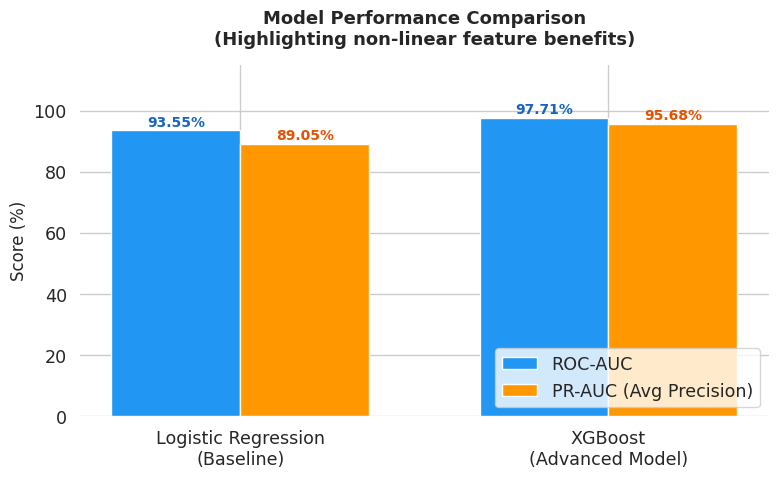

XGBoost improves ROC-AUC by +4.16% over baseline.
XGBoost improves PR-AUC (Average Precision) by +6.63% over baseline.


In [23]:
# Model Comparison Visualization
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(2)
width = 0.35

# Metric scores
roc_scores = [lr_auc * 100, roc * 100]
pr_scores = [lr_ap * 100, ap * 100]

ax.bar(x_pos - width/2, roc_scores, width, label='ROC-AUC', color='#2196F3')
ax.bar(x_pos + width/2, pr_scores, width, label='PR-AUC (Avg Precision)', color='#FF9800')

ax.set_xticks(x_pos)
ax.set_xticklabels(['Logistic Regression\n(Baseline)', 'XGBoost\n(Advanced Model)'])
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Model Performance Comparison\n(Highlighting non-linear feature benefits)', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right')

# Annotate bars
for i, val in enumerate(roc_scores):
    ax.text(i - width/2, val + 1.5, f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold', color='#1565C0')
for i, val in enumerate(pr_scores):
    ax.text(i + width/2, val + 1.5, f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold', color='#E65100')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print(f"XGBoost improves ROC-AUC by {roc*100 - lr_auc*100:+.2f}% over baseline.")
print(f"XGBoost improves PR-AUC (Average Precision) by {ap*100 - lr_ap*100:+.2f}% over baseline.")

### Model Performance Comparison

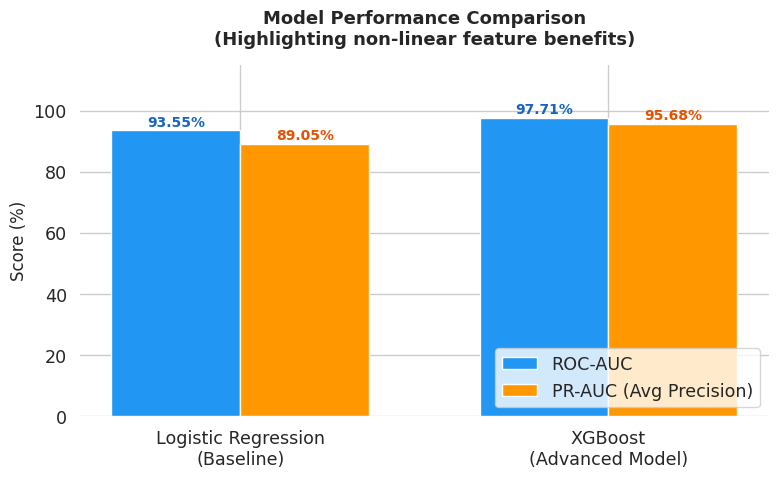

XGBoost improves ROC-AUC by +4.16% over baseline.
XGBoost improves PR-AUC (Average Precision) by +6.63% over baseline.


In [24]:
# Model Comparison Visualization
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(2)
width = 0.35

# Metric scores
roc_scores = [lr_auc * 100, roc * 100]
pr_scores = [lr_ap * 100, ap * 100]

ax.bar(x_pos - width/2, roc_scores, width, label='ROC-AUC', color='#2196F3')
ax.bar(x_pos + width/2, pr_scores, width, label='PR-AUC (Avg Precision)', color='#FF9800')

ax.set_xticks(x_pos)
ax.set_xticklabels(['Logistic Regression\n(Baseline)', 'XGBoost\n(Advanced Model)'])
ax.set_ylabel('Score (%)')
ax.set_ylim(0, 115)
ax.set_title('Model Performance Comparison\n(Highlighting non-linear feature benefits)', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right')

# Annotate bars
for i, val in enumerate(roc_scores):
    ax.text(i - width/2, val + 1.5, f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold', color='#1565C0')
for i, val in enumerate(pr_scores):
    ax.text(i + width/2, val + 1.5, f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold', color='#E65100')

sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print(f"XGBoost improves ROC-AUC by {roc*100 - lr_auc*100:+.2f}% over baseline.")
print(f"XGBoost improves PR-AUC (Average Precision) by {ap*100 - lr_ap*100:+.2f}% over baseline.")

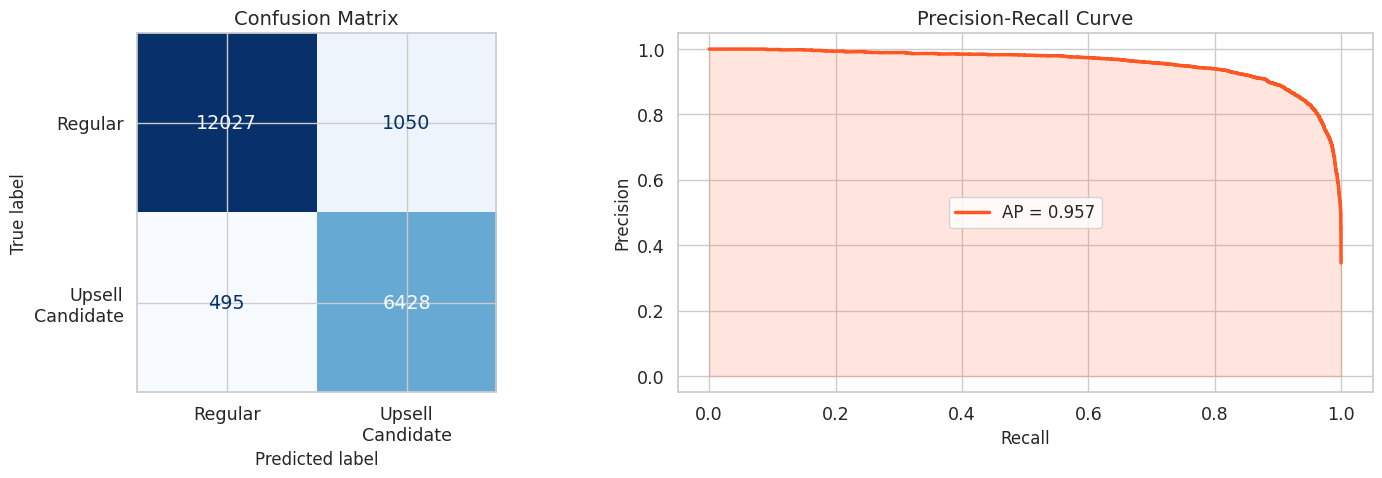

In [25]:
# Confusion Matrix Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Regular', 'Upsell\nCandidate'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title('Confusion Matrix')

# Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_test, y_prob)
axes[1].plot(rec, prec, color='#FF5722', lw=2.5, label=f'AP = {ap:.3f}')
axes[1].fill_between(rec, prec, alpha=0.15, color='#FF5722')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=12)

plt.tight_layout()
plt.show()

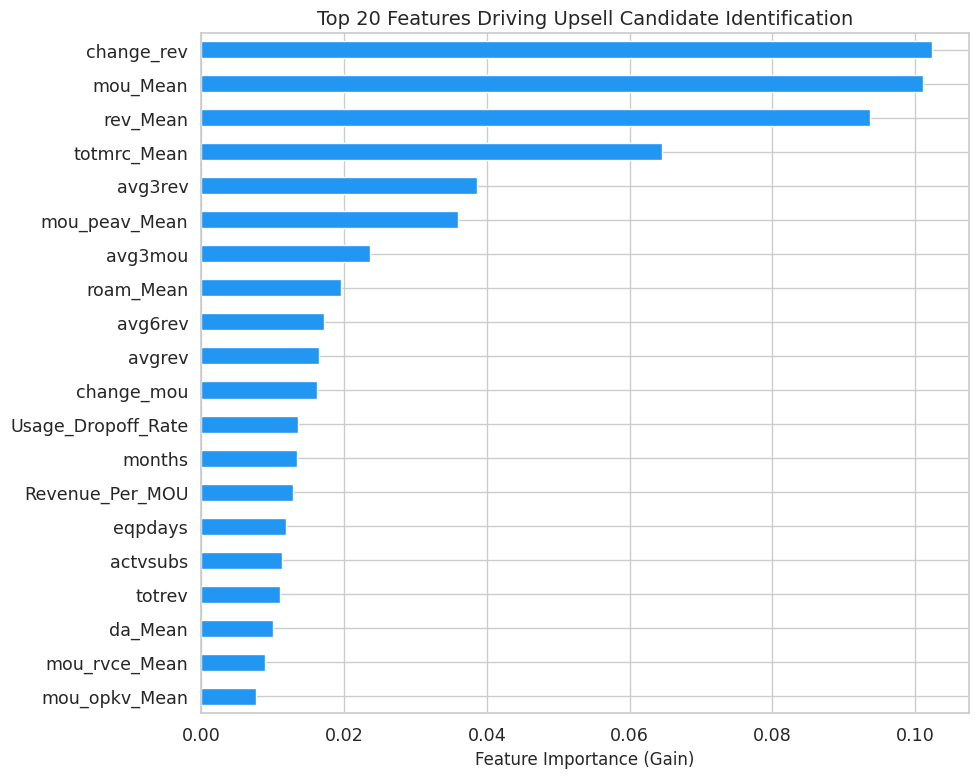

In [26]:
# Feature Importance (Top 20)
importance = pd.Series(model.feature_importances_, index=feature_cols)
top20 = importance.nlargest(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot.barh(ax=ax, color='#2196F3', edgecolor='white')
ax.set_xlabel('Feature Importance (Gain)')
ax.set_title('Top 20 Features Driving Upsell Candidate Identification')
plt.tight_layout()
plt.show()

## Business Verification: Financial Impact Projection

In [27]:
# Financial Impact Calculation
# Campaign Parameters
CONVERSION_RATE       = 0.10    # 10% of contacted candidates convert
ARPU_INCREASE_JPY     = 5000    # ¥5,000/month ARPU lift per conversion
CHURN_PREVENTION_RATE = 0.20    # 20% of converts would have churned otherwise
CLV_MONTHS            = 24      # Customer lifetime horizon
CHURN_SAVE_VALUE_JPY  = 8000    # Monthly revenue of a saved customer
CAMPAIGN_COST_PER_CONTACT_JPY = 500  # Cost to contact each candidate (call center + offer)

# Model Outputs
cm = confusion_matrix(y_test, y_pred)
tp_test = cm[1, 1]
fp_test = cm[0, 1]
fn_test = cm[1, 0]

# Scale to full subscriber base (test was 20%)
scaling_factor = 5  # full base / test set
tp_full = tp_test * scaling_factor
fp_full = fp_test * scaling_factor
total_contacted = (tp_test + fp_test) * scaling_factor

# Revenue Calculations
# ARPU Uplift from plan migration
converted_customers = int(tp_full * CONVERSION_RATE)
annual_arpu_lift = converted_customers * ARPU_INCREASE_JPY * 12

# Churn Prevention Value
churners_saved = int(converted_customers * CHURN_PREVENTION_RATE)
annual_churn_save = churners_saved * CHURN_SAVE_VALUE_JPY * CLV_MONTHS

# Campaign Cost
total_campaign_cost = int(total_contacted * CAMPAIGN_COST_PER_CONTACT_JPY)

# NET Impact
total_revenue_lift = annual_arpu_lift + annual_churn_save
net_impact = total_revenue_lift - total_campaign_cost
roi = (net_impact / total_campaign_cost) * 100 if total_campaign_cost > 0 else 0

# Display Results
print(f'\n  Model Performance (scaled to full 100K base):')
print(f'    True Positives identified:        {tp_full:>8,} customers')
print(f'    False Positives (wasted contacts): {fp_full:>8,} customers')
print(f'    Total customers to contact:       {total_contacted:>8,} customers')
print(f'\n  Revenue Stream 1 — ARPU Uplift:')
print(f'    Converted to premium plan:         {converted_customers:>8,} customers')
print(f'    Annual ARPU lift:               ¥{annual_arpu_lift:>12,}')
print(f'\n  Revenue Stream 2 — Churn Prevention:')
print(f'    Churners prevented:                {churners_saved:>8,} customers')
print(f'    Churn-save value ({CLV_MONTHS}mo):        ¥{annual_churn_save:>12,}')
print(f'\n  Costs:')
print(f'    Campaign cost:                  ¥{total_campaign_cost:>12,}')
print(f'\n  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
print(f'   TOTAL PROJECTED REVENUE LIFT:  ¥{total_revenue_lift:>12,}')
print(f'   NET IMPACT (after costs):      ¥{net_impact:>12,}')
print(f'   CAMPAIGN ROI:                     {roi:>10.1f}%')
print(f'  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')


  Model Performance (scaled to full 100K base):
    True Positives identified:          32,140 customers
    False Positives (wasted contacts):    5,250 customers
    Total customers to contact:         37,390 customers

  Revenue Stream 1 — ARPU Uplift:
    Converted to premium plan:            3,214 customers
    Annual ARPU lift:               ¥ 192,840,000

  Revenue Stream 2 — Churn Prevention:
    Churners prevented:                     642 customers
    Churn-save value (24mo):        ¥ 123,264,000

  Costs:
    Campaign cost:                  ¥  18,695,000

  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   TOTAL PROJECTED REVENUE LIFT:  ¥ 316,104,000
   NET IMPACT (after costs):      ¥ 297,409,000
   CAMPAIGN ROI:                         1590.8%
  ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


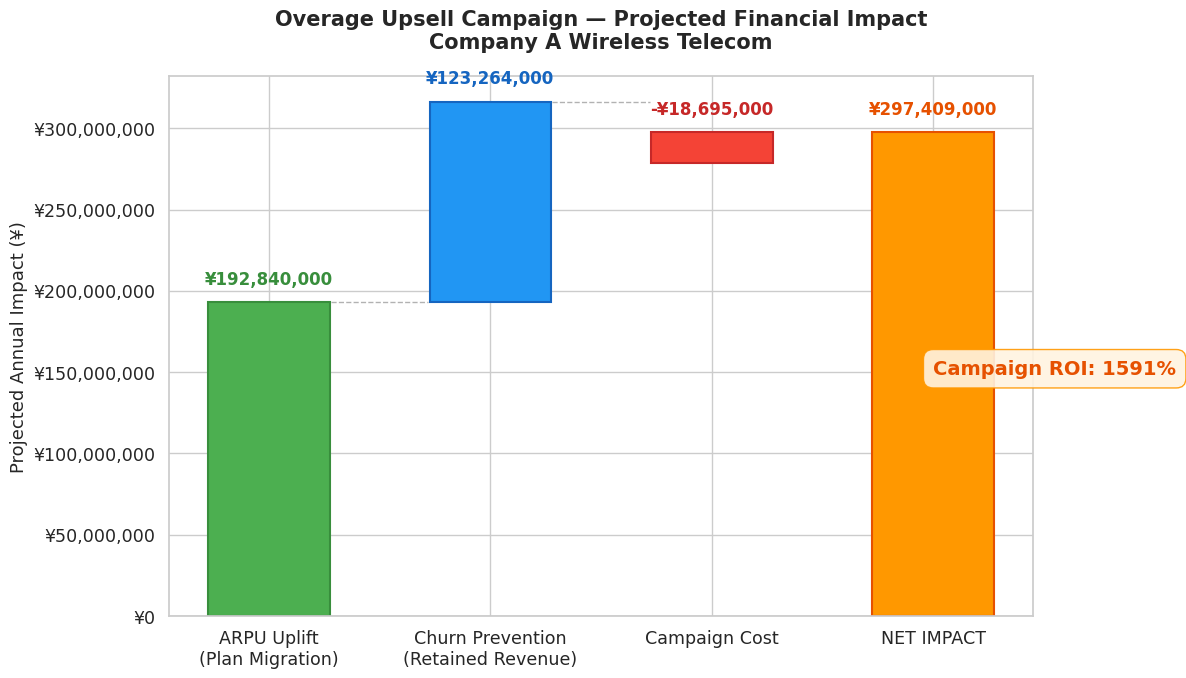

In [28]:
# Executive Visualization: Waterfall Chart
# Data for waterfall
categories = [
    'ARPU Uplift\n(Plan Migration)',
    'Churn Prevention\n(Retained Revenue)',
    'Campaign Cost',
    'NET IMPACT'
]
values = [
    annual_arpu_lift,
    annual_churn_save,
    -total_campaign_cost,
    net_impact
]

# Calculate waterfall positions
cumulative = [0]
for v in values[:-1]:
    cumulative.append(cumulative[-1] + v)

# Colors
colors = ['#4CAF50', '#2196F3', '#F44336', '#FF9800']
edge_colors = ['#388E3C', '#1565C0', '#C62828', '#E65100']

fig, ax = plt.subplots(figsize=(12, 7))

for i, (cat, val, bottom) in enumerate(zip(categories, values, cumulative)):
    if i == len(categories) - 1:  # NET bar starts from 0
        bar = ax.bar(cat, val, bottom=0, color=colors[i],
                     edgecolor=edge_colors[i], linewidth=1.5, width=0.55)
    else:
        bar = ax.bar(cat, val, bottom=bottom if val >= 0 else bottom + val,
                     color=colors[i], edgecolor=edge_colors[i],
                     linewidth=1.5, width=0.55)

    # Value label
    label_y = (bottom + val) if i < len(categories) - 1 else val
    label_text = f'¥{abs(val):,.0f}'
    if val < 0:
        label_text = f'-¥{abs(val):,.0f}'
    ax.text(i, label_y + net_impact * 0.03, label_text,
            ha='center', va='bottom', fontsize=12, fontweight='bold',
            color=edge_colors[i])

# Connector lines between bars
for i in range(len(values) - 2):
    top = cumulative[i] + values[i]
    ax.plot([i + 0.28, i + 0.72], [top, top], color='gray',
            ls='--', lw=1, alpha=0.6)

ax.set_ylabel('Projected Annual Impact (¥)', fontsize=13)
ax.set_title('Overage Upsell Campaign — Projected Financial Impact\n'
             'Company A Wireless Telecom',
             fontsize=15, fontweight='bold', pad=20)

# Format y-axis
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'¥{x:,.0f}'))
ax.axhline(0, color='black', lw=0.8)

# ROI annotation
ax.annotate(f'Campaign ROI: {roi:.0f}%',
            xy=(3, net_impact * 0.5), fontsize=14, fontweight='bold',
            color='#E65100',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3E0',
                      edgecolor='#FF9800', alpha=0.9))

plt.tight_layout()
plt.show()

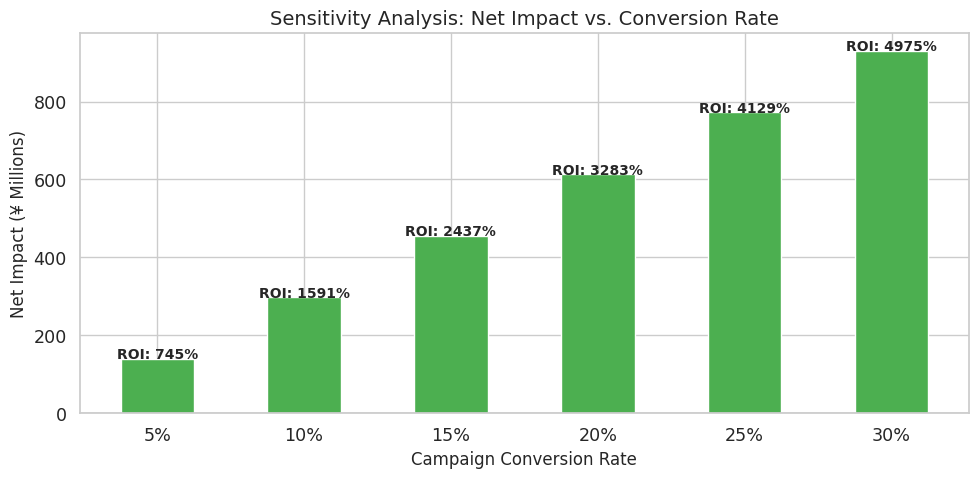

,Conversion Rate,Converted,ARPU Lift (¥),Churn Save (¥),Net Impact (¥),ROI (%)
0,5%,1607,"¥96,420,000","¥61,632,000","¥139,357,000",745%
1,10%,3214,"¥192,840,000","¥123,264,000","¥297,409,000",1591%
2,15%,4821,"¥289,260,000","¥185,088,000","¥455,653,000",2437%
3,20%,6428,"¥385,680,000","¥246,720,000","¥613,705,000",3283%
4,25%,8035,"¥482,100,000","¥308,544,000","¥771,949,000",4129%
5,30%,9642,"¥578,520,000","¥370,176,000","¥930,001,000",4975%


In [29]:
# Sensitivity Analysis
conv_rates = np.arange(0.05, 0.31, 0.05)
results = []

for cr in conv_rates:
    conv = int(tp_full * cr)
    saved = int(conv * CHURN_PREVENTION_RATE)
    arpu = conv * ARPU_INCREASE_JPY * 12
    churn_v = saved * CHURN_SAVE_VALUE_JPY * CLV_MONTHS
    cost = total_campaign_cost
    net = arpu + churn_v - cost
    results.append({
        'Conversion Rate': f'{cr*100:.0f}%',
        'Converted': conv,
        'ARPU Lift (¥)': arpu,
        'Churn Save (¥)': churn_v,
        'Net Impact (¥)': net,
        'ROI (%)': (net / cost * 100) if cost > 0 else 0
    })

sensitivity_df = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(sensitivity_df['Conversion Rate'],
       sensitivity_df['Net Impact (¥)'] / 1e6,
       color=['#F44336' if v < 0 else '#4CAF50'
              for v in sensitivity_df['Net Impact (¥)']],
       edgecolor='white', width=0.5)

for i, row in sensitivity_df.iterrows():
    ax.text(i, row['Net Impact (¥)'] / 1e6 + 0.5,
            f"ROI: {row['ROI (%)']:.0f}%",
            ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Campaign Conversion Rate')
ax.set_ylabel('Net Impact (¥ Millions)')
ax.set_title('Sensitivity Analysis: Net Impact vs. Conversion Rate')
ax.axhline(0, color='black', lw=0.8)
plt.tight_layout()
plt.show()

sensitivity_df.style.format({
    'ARPU Lift (¥)': '¥{:,.0f}',
    'Churn Save (¥)': '¥{:,.0f}',
    'Net Impact (¥)': '¥{:,.0f}',
    'ROI (%)': '{:.0f}%'
})